In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Inflation by Month.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "scarfsman/uk-inflation-data-1989-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_525/3158951361.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'uk-inflation-data-1989-2022' dataset.
First 5 records:    Year Month  Inflation
0  1989   JAN        5.7
1  1989   FEB        5.8
2  1989   MAR        5.9
3  1989   APR        5.6
4  1989   MAY        5.9


Text(0.5, 1.0, 'UK Monthly Inflation, 1989-2022')

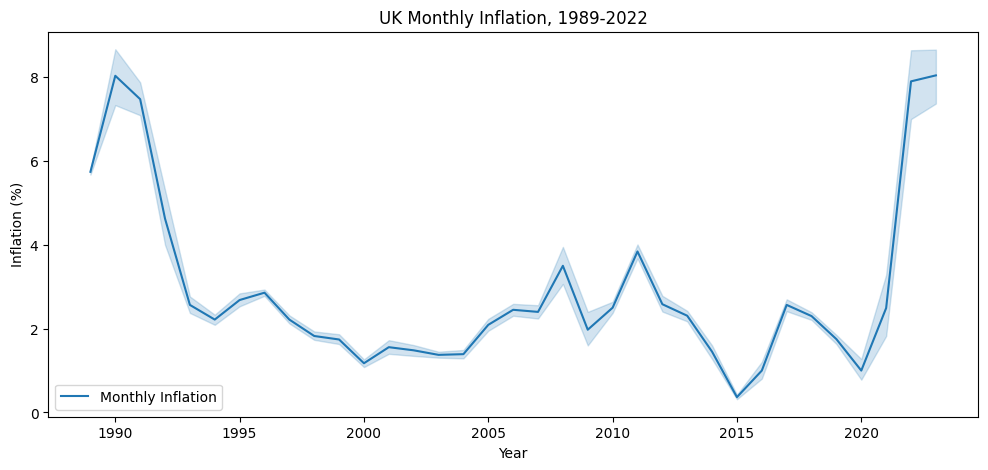

In [ ]:
#time series plot for actual inflation
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


plt.figure( figsize = ( 12, 5))

sns.lineplot( x = 'Year',
             y = 'Inflation',
             data = df,
             label = 'Monthly Inflation')

plt.xlabel( 'Year')
plt.ylabel( 'Inflation (%)')
plt.title( 'UK Monthly Inflation, 1989-2022' )


In [ ]:
#summary statistics

df['Inflation'].describe().round(2)

,Inflation
count,415.00
mean,2.84
std,2.05
min,0.20
25%,1.60
50%,2.30
75%,3.00
max,9.60


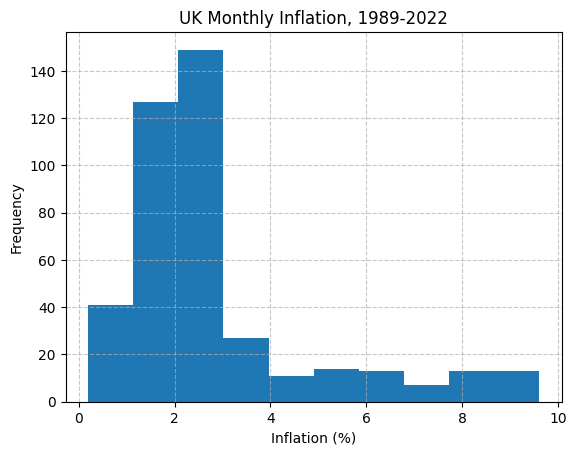

In [ ]:
#histogram

plt.hist(df['Inflation'])
plt.xlabel("Inflation (%)")
plt.ylabel("Frequency")
plt.title("UK Monthly Inflation, 1989-2022")
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for easier reading
plt.show()


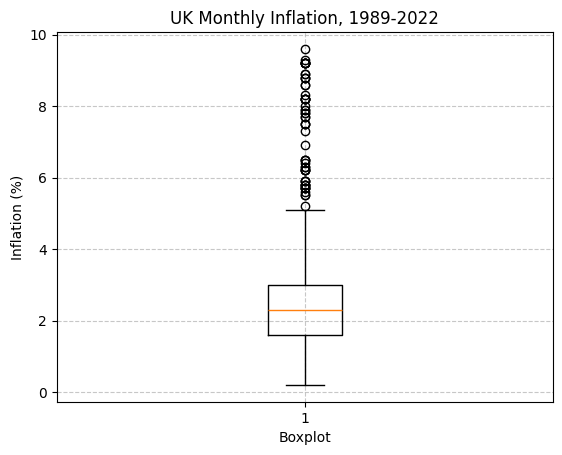

In [ ]:
#boxplot

plt.boxplot(df['Inflation'])
plt.ylabel("Inflation (%)")
plt.xlabel("Boxplot")
plt.title("UK Monthly Inflation, 1989-2022")
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for easier reading

In [ ]:
#creating a rolling average

df['inflation-rolling-avg'] = df['Inflation'].rolling(window=12).mean()
print(df['inflation-rolling-avg'])

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
         ...   
410    8.758333
411    8.758333
412    8.758333
413    8.683333
414    8.483333
Name: inflation-rolling-avg, Length: 415, dtype: float64


Text(0.5, 1.0, 'UK Monthly Inflation, 1989-2022')

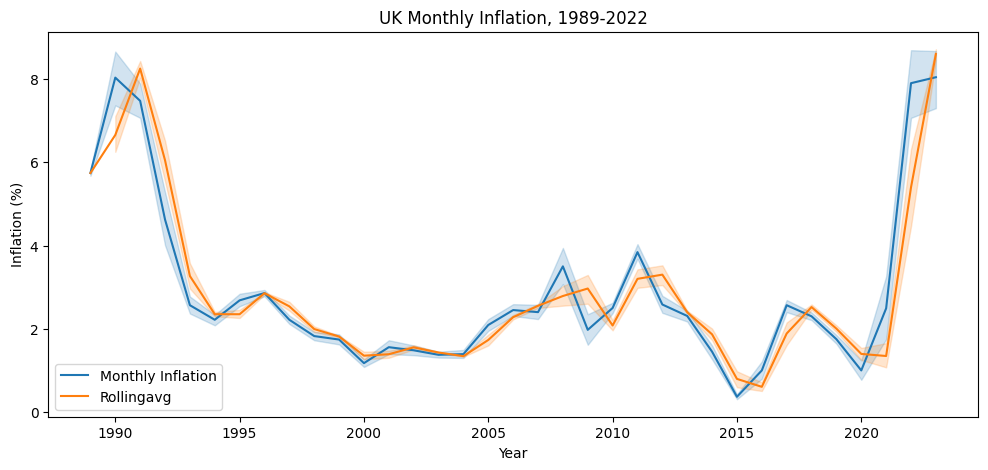

In [ ]:
#plotting actual inflation and rolling average on same graph

plt.figure( figsize = ( 12, 5))

sns.lineplot( x = 'Year',
             y = 'Inflation',
             data = df,
             label = 'Monthly Inflation')

sns.lineplot( x = 'Year',
             y = 'inflation-rolling-avg',
             data = df,
             label = 'Rollingavg')

plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.title('UK Monthly Inflation, 1989-2022')

In [ ]:
#rolling standard deviation

df['rolling_std'] = df["Inflation"].rolling(window=12).std()
print(df['rolling_std'])

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
         ...   
410    0.556708
411    0.556708
412    0.556708
413    0.684681
414    0.947565
Name: rolling_std, Length: 415, dtype: float64


Text(0.5, 1.0, 'UK Monthly Inflation, 1989-2022')

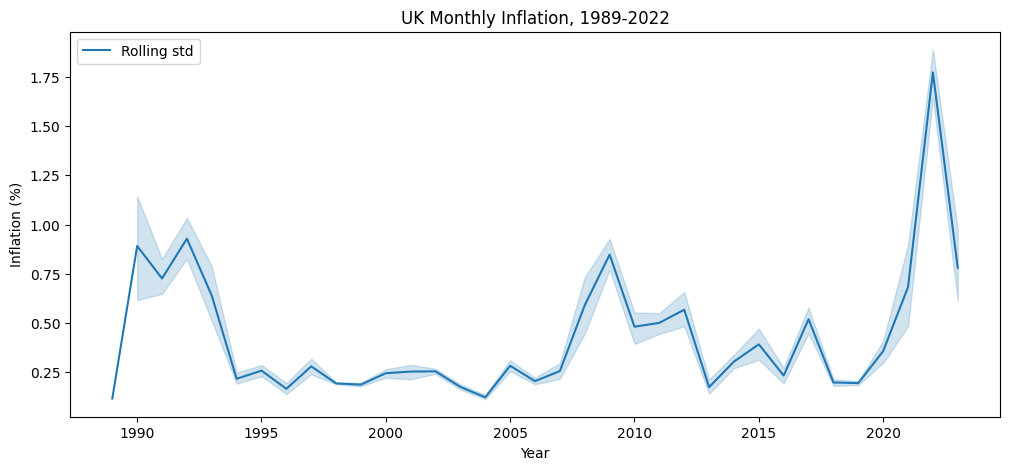

In [ ]:
#plotting rolling standard deviation

plt.figure( figsize = ( 12, 5))

sns.lineplot( x = 'Year',
             y = 'rolling_std',
             data = df,
             label = 'Rolling std')
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.title('UK Monthly Inflation, 1989-2022')

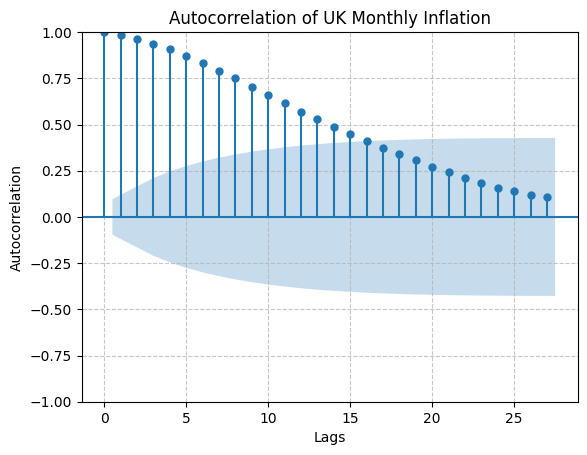

In [ ]:
#plotting ACF
import statsmodels.graphics.tsaplots as tsaplots

tsaplots.plot_acf(df['Inflation'], ax=None,
                                       lags=None,
                                       alpha=0.05,
                                       use_vlines=True,
                                       adjusted=False,
                                       fft=False,
                                       missing='none',
                                       title='Autocorrelation of UK Monthly Inflation',
                                       zero=True,
                                       auto_ylims=False,
                                       bartlett_confint=True,
                                       vlines_kwargs=None)
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

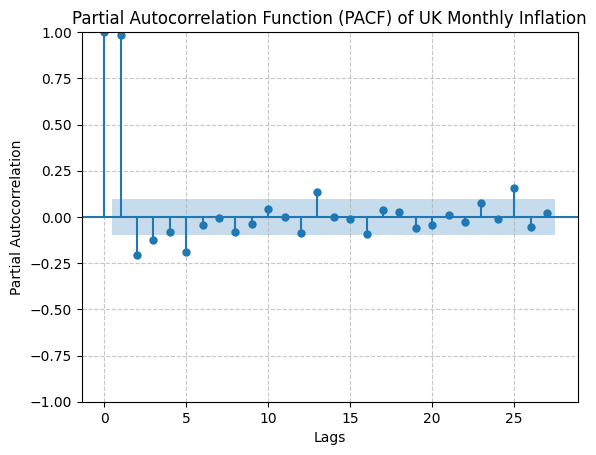

In [ ]:
#plotting PACF
tsaplots.plot_pacf(df['Inflation'], ax=None,
                                       lags=None,
                                       alpha=0.05,
                                       use_vlines=True,
                                       title='Partial Autocorrelation Function (PACF) of UK Monthly Inflation')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#ADF test for stationarity/ presence of unit roots

from statsmodels.tsa.stattools import adfuller


def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [ ]:
#null hypothesis = unit root, alternative hypothesis = no unit root
#here we reject H0 at the 10%, 5%, and 1% levels and therefore shows we have no unit root which is good

adf_test(df["Inflation"])

Results of Dickey-Fuller Test:
Test Statistic                  -3.987353
p-value                          0.001478
#Lags Used                      18.000000
Number of Observations Used    396.000000
Critical Value (1%)             -3.446972
Critical Value (5%)             -2.868866
Critical Value (10%)            -2.570673
dtype: float64


In [ ]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'], format='%Y-%b')
df.set_index('Date', inplace=True)

In [ ]:
# Split data into training and testing sets (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_data, test_data = df['Inflation'][0:train_size], df['Inflation'][train_size:]

print(f"Training set size: {len(train_data)}")
print(f"Testing set size: {len(test_data)}")

Training set size: 332
Testing set size: 83


In [ ]:
model_arima201 = ARIMA(train_data, order=(2, 0, 1))
model_fit_arima201 = model_arima201.fit()

#Make predictions on the test set
predictions_test_201 = model_fit_arima201.predict(start=start_index, end=end_index, dynamic=False)

print('ARIMA(2,0,1) Predictions on test set (first 5):\n', predictions_test_201.head())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA(2,0,1) Predictions on test set (first 5):
 2016-09-01    1.061815
2016-10-01    1.120481
2016-11-01    1.176313
2016-12-01    1.229581
2017-01-01    1.280514
Freq: MS, Name: predicted_mean, dtype: float64


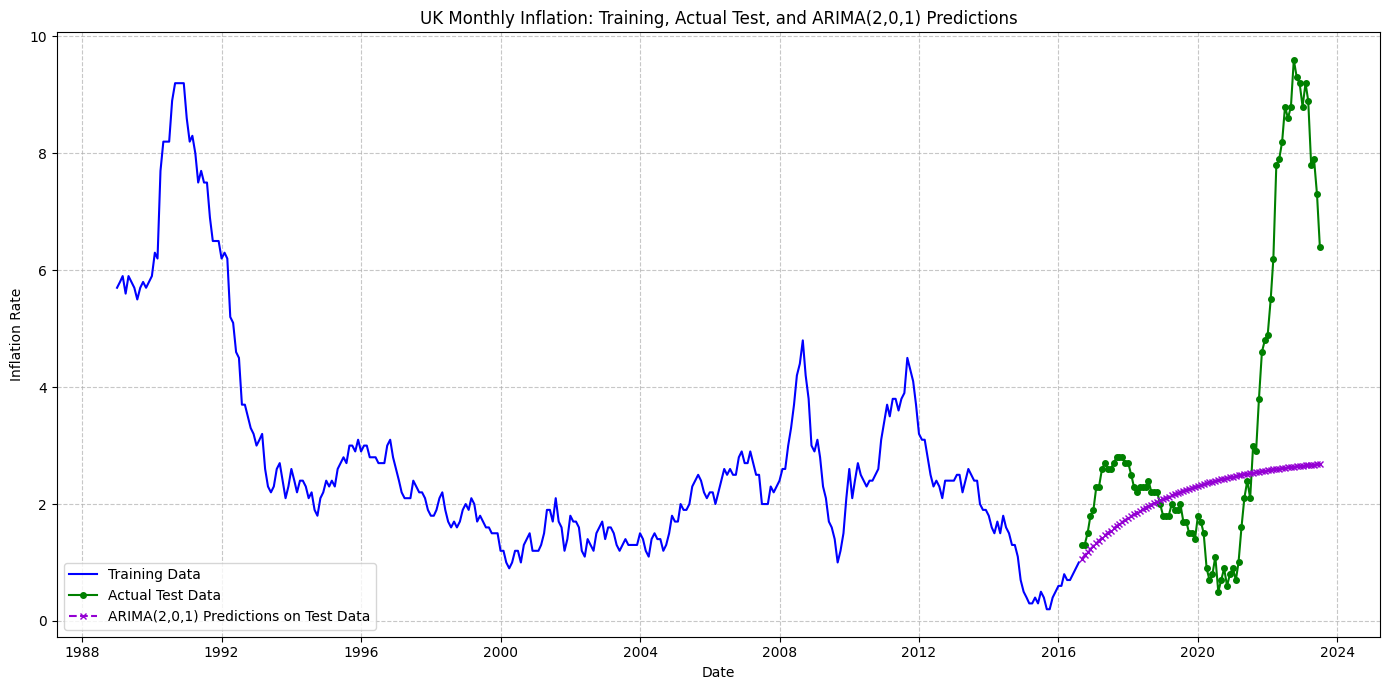

In [ ]:
#predictions on test set for ARIMA (2,0,1)
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data.values, label='Training Data', color='blue')
plt.plot(test_data.index, test_data.values, label='Actual Test Data', color='green', marker='o', markersize=4)
plt.plot(predictions_test_201.index, predictions_test_201.values, label='ARIMA(2,0,1) Predictions on Test Data', color='darkviolet', linestyle='--', marker='x', markersize=4)
plt.xlabel('Date')
plt.ylabel('Inflation Rate')
plt.title('UK Monthly Inflation: Training, Actual Test, and ARIMA(2,0,1) Predictions')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

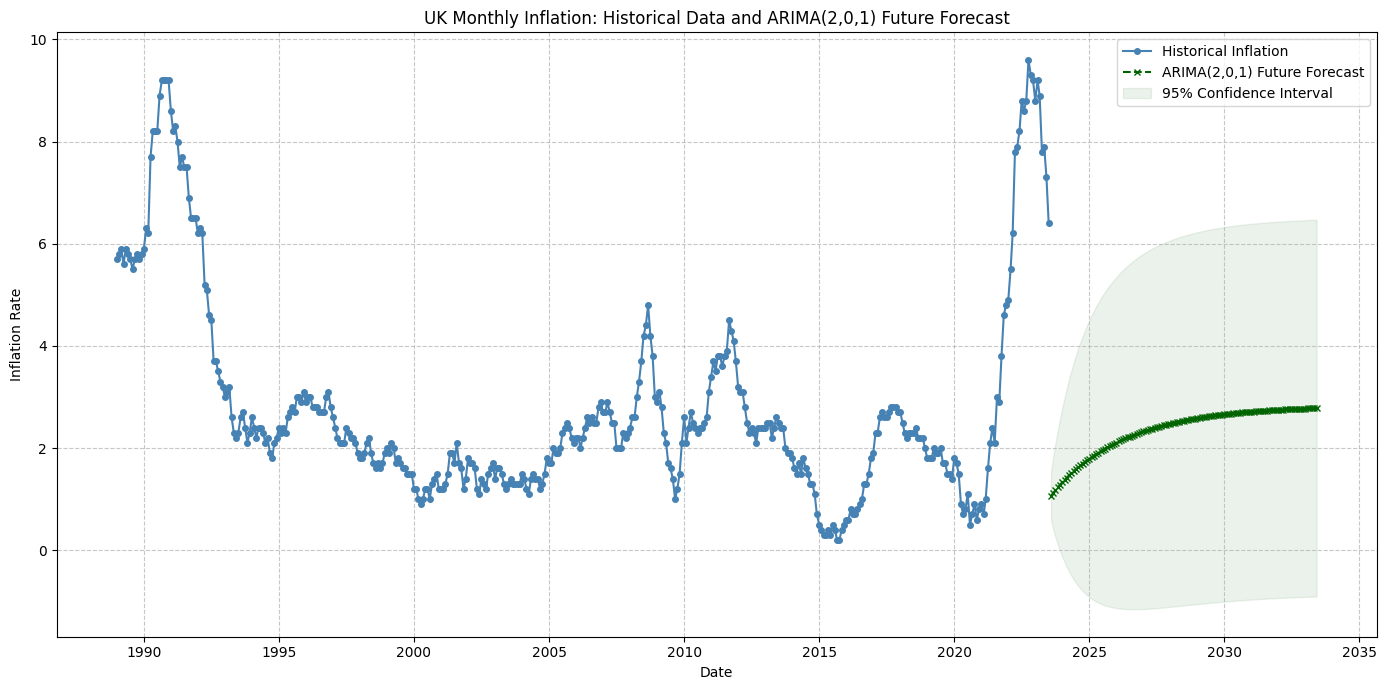

In [ ]:
#forecasting future points for ARIMA(2,0,1) with confidence intervals
forecast_result_future_201 = model_fit_arima201.get_forecast(steps=len(df) - len(train_data) + 36)
predictions_future_201 = forecast_result_future_201.predicted_mean
conf_int_future_201 = forecast_result_future_201.conf_int()

last_date_df = df.index[-1]
forecast_dates_future_201 = pd.date_range(start=last_date_df, periods=len(predictions_future_201) + 1, freq='MS')[1:]

predictions_future_series_201 = pd.Series(predictions_future_201.values, index=forecast_dates_future_201)
lower_bound_future_201 = pd.Series(conf_int_future_201.iloc[:, 0].values, index=forecast_dates_future_201)
upper_bound_future_201 = pd.Series(conf_int_future_201.iloc[:, 1].values, index=forecast_dates_future_201)

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Inflation'], label='Historical Inflation', color='steelblue', marker='o', markersize=4)
plt.plot(predictions_future_series_201.index, predictions_future_series_201.values, label='ARIMA(2,0,1) Future Forecast', color='darkgreen', linestyle='--', marker='x', markersize=4)
plt.fill_between(forecast_dates_future_201, lower_bound_future_201, upper_bound_future_201, color='darkgreen', alpha=0.08, label='95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Inflation Rate')
plt.title('UK Monthly Inflation: Historical Data and ARIMA(2,0,1) Future Forecast')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

-need to fit and define data for each ARIMA model for it to make predictions in order to assess using AIC, BIC, RMSE and MAE

In [ ]:
#Fit ARIMA(2,0,0) model on training data
from statsmodels.tsa.arima.model import ARIMA
model_arima200 = ARIMA(train_data, order=(2, 0, 0))
model_fit_arima200 = model_arima200.fit()

#Make predictions on the test set
predictions_test_200 = model_fit_arima200.predict(start=start_index, end=end_index, dynamic=False)

print('ARIMA(2,0,0) Predictions on test set (first 5):\n', predictions_test_200.head())
model_fit_train = model_fit_arima200 # Assigning for consistency with the evaluation dictionary
predictions_test = predictions_test_200 # Assigning for consistency with the evaluation dictionary

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA(2,0,0) Predictions on test set (first 5):
 2016-09-01    1.038280
2016-10-01    1.064066
2016-11-01    1.087146
2016-12-01    1.109471
2017-01-01    1.131431
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
#Fit ARIMA(1,0,0) model on training data
model_arima100 = ARIMA(train_data, order=(1, 0, 0))
model_fit_arima100 = model_arima100.fit()

#Make predictions on the test set
predictions_test_100 = model_fit_arima100.predict(start=start_index, end=end_index, dynamic=False)

print('ARIMA(1,0,0) Predictions on test set (first 5):\n', predictions_test_100.head())

ARIMA(1,0,0) Predictions on test set (first 5):
 2016-09-01    1.015236
2016-10-01    1.030354
2016-11-01    1.045357
2016-12-01    1.060246
2017-01-01    1.075020
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
#Fit ARIMA(1,0,1) model on training data
model_arima101 = ARIMA(train_data, order=(1, 0, 1))
model_fit_arima101 = model_arima101.fit()

#Make predictions on the test set
predictions_test_101 = model_fit_arima101.predict(start=start_index, end=end_index, dynamic=False)

print('ARIMA(1,0,1) Predictions on test set (first 5):\n', predictions_test_101.head())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA(1,0,1) Predictions on test set (first 5):
 2016-09-01    1.032088
2016-10-01    1.052265
2016-11-01    1.072229
2016-12-01    1.091982
2017-01-01    1.111526
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
#Fit ARIMA(2,0,2) model on training data
model_arima202 = ARIMA(train_data, order=(2, 0, 2))
model_fit_arima202 = model_arima202.fit()

#Make predictions on the test set
predictions_test_202 = model_fit_arima202.predict(start=start_index, end=end_index, dynamic=False)

print('ARIMA(2,0,2) Predictions on test set (first 5):\n', predictions_test_202.head())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

ARIMA(2,0,2) Predictions on test set (first 5):
 2016-09-01    1.036420
2016-10-01    1.061300
2016-11-01    1.081608
2016-12-01    1.103751
2017-01-01    1.124633
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
#AIC, BIC, MAE, RMSE evaluation table
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

#list to store model performance metrics
model_performance = []

models = {
    'ARIMA(2,0,0)': {'model_fit': model_fit_train, 'predictions_test': predictions_test},
    'ARIMA(1,0,0)': {'model_fit': model_fit_arima100, 'predictions_test': predictions_test_100},
    'ARIMA(1,0,1)': {'model_fit': model_fit_arima101, 'predictions_test': predictions_test_101},
    'ARIMA(2,0,1)': {'model_fit': model_fit_arima201, 'predictions_test': predictions_test_201},
    'ARIMA(2,0,2)': {'model_fit': model_fit_arima202, 'predictions_test': predictions_test_202}
}

for model_name, data in models.items():
    model_fit = data['model_fit']
    predictions = data['predictions_test']

    #ensure predictions align with test_data for metric calculation
    #only consider the part of test_data that corresponds to the predictions
    aligned_test_data = test_data[predictions.index]

    # Calculate RMSE and MAE
    rmse = np.sqrt(mean_squared_error(aligned_test_data, predictions))
    mae = mean_absolute_error(aligned_test_data, predictions)

    model_performance.append({
        'Model': model_name,
        'AIC': model_fit.aic,
        'BIC': model_fit.bic,
        'RMSE': rmse,
        'MAE': mae
    })

# Create a DataFrame from the performance metrics
performance_df = pd.DataFrame(model_performance)

# Display the performance table
display(performance_df.round(3))


,Model,AIC,BIC,RMSE,MAE
0,"ARIMA(2,0,0)",18.212,33.433,2.981,1.971
1,"ARIMA(1,0,0)",29.213,40.629,3.123,2.076
2,"ARIMA(1,0,1)",20.058,35.278,3.023,2.003
3,"ARIMA(2,0,1)",13.257,32.283,2.764,1.863
4,"ARIMA(2,0,2)",22.184,45.015,2.993,1.981


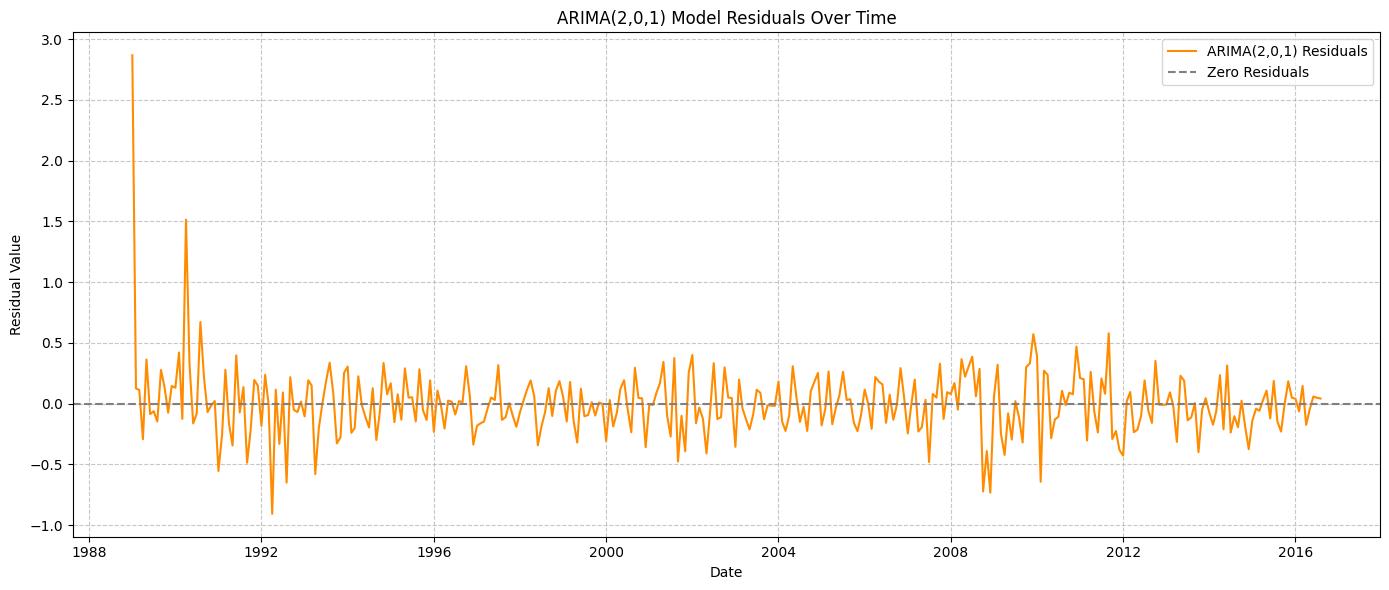

In [ ]:
# Get the residuals from the fitted model for the original ARIMA(2,0,1)
residuals_201_original = model_fit_arima201.resid

# Plot residuals over time
plt.figure(figsize=(14, 6))
plt.plot(residuals_201_original.index, residuals_201_original.values, label='ARIMA(2,0,1) Residuals', color='darkorange')
plt.axhline(0, linestyle='--', color='gray', label='Zero Residuals')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.title('ARIMA(2,0,1) Model Residuals Over Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

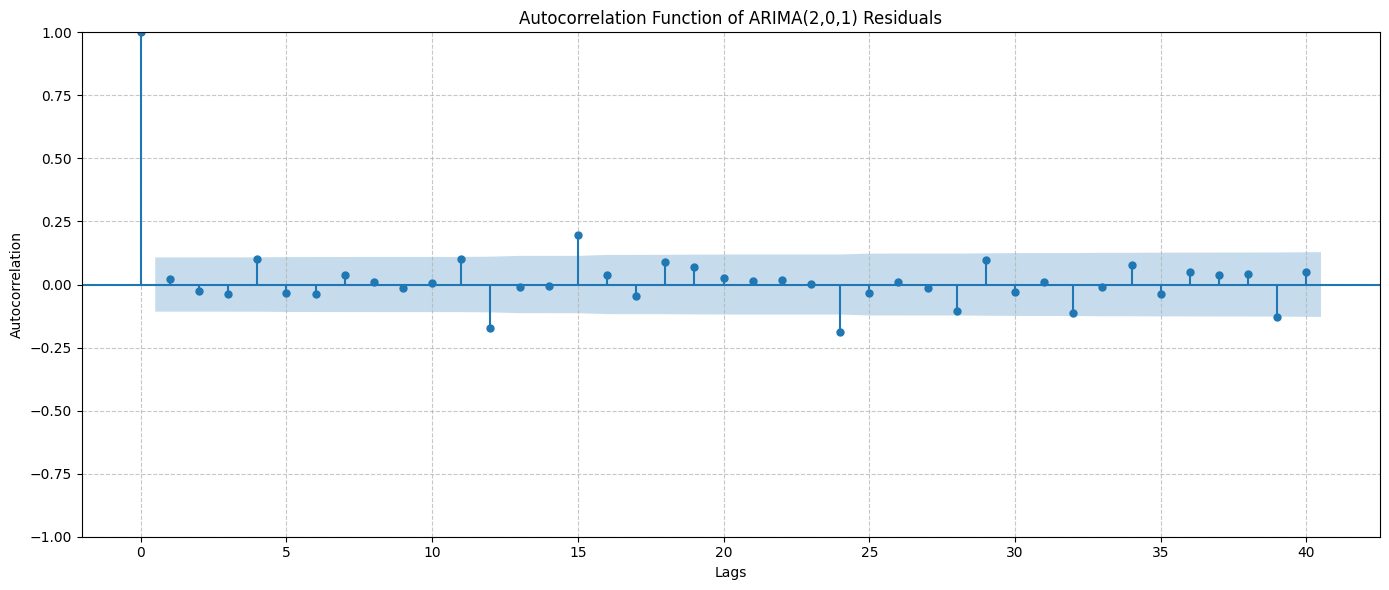

In [ ]:
# Plot ACF of residuals for the original ARIMA(2,0,1)
plt.figure(figsize=(14, 6))
tsaplots.plot_acf(residuals_201_original, lags=40, ax=plt.gca(), title='Autocorrelation Function of ARIMA(2,0,1) Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()